In [9]:
# Modelo: Regresión Logística
# Autor: Apellido

In [10]:
# Librerías importadas
import pandas as pd
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression


In [11]:
# Carga de datos 

train = pd.read_csv("../../../data/raw/train.csv")

print("Tamaño del Dataset Train:", train.shape)

#print("Datos cargados: ")
#print(train.head())

Tamaño del Dataset Train: (110100, 25)


In [12]:
# Variables

features = [
    "banda_riesgo",
    "numero_productos",
    "activo_movil",
    "tiene_tarjeta_credito",
    "dias_ultima_transaccion",
]


target = "objetivo"

In [13]:
# Usamos solo los meses enero a octubre , y diciembre como salida

train_model = train[train["mes"] <= 202610].copy()
validacion = train[train["mes"] == 202611].copy()

In [14]:
print("\nEntrenamiento:", train_model.shape)
print("Validación:", validacion.shape)


Entrenamiento: (100600, 25)
Validación: (9500, 25)


In [15]:
# Separa X y Y

X_train = train_model[features]
y_train = train_model[target]

X_valid = validacion[features]
y_valid = validacion[target]

In [20]:
# Comprobación 

print(X_train)
print(y_train)

       banda_riesgo  numero_productos  activo_movil  tiene_tarjeta_credito  \
0               low                 2          True                  False   
1               low                 2          True                  False   
2              high                 2          True                   True   
3              high                 2         False                  False   
4            medium                 1          True                   True   
...             ...               ...           ...                    ...   
100595         high                 2          True                  False   
100596       medium                 1          True                   True   
100597       medium                 2          True                   True   
100598         high                 4          True                  False   
100599          low                 1         False                   True   

        dias_ultima_transaccion  
0                            

In [21]:
# Definimos las variables categoricas, numéricas y booleanas
categoricas = [
    "banda_riesgo",
]

numericas = [
    "numero_productos",
    "dias_ultima_transaccion",
]

booleanas = [
    "activo_movil",
    "tiene_tarjeta_credito",
]

# Realizamos el proprocesamiento

preprocesamiento = ColumnTransformer(
    transformers=[
        (
            "categoricas",
            OneHotEncoder(handle_unknown="ignore"), # Vectorización
            categoricas,
        ),
        (
            "numericas",
            "passthrough",
            numericas,
        ),
        (
            "booleanas",
            "passthrough",
            booleanas,
        ),
    ]
)

In [26]:
modelo = Pipeline(
    steps=[
        ("preprocesamiento", preprocesamiento),
        (
            "modelo",
            LogisticRegression(
                max_iter=9000,
                random_state=42,
            ),
        ),
    ]
)

In [27]:
modelo.fit(X_train, y_train)
probabilidades = modelo.predict_proba(X_valid)[:, 1]

In [28]:
# Evaluación
auc = roc_auc_score(y_valid, probabilidades)
gini = 2 * auc - 1

print("\n==============================")
print("RESULTADOS BASELINE")
print("==============================")
print(f"AUC:  {auc:.6f}")
print(f"Gini: {gini:.6f}")


RESULTADOS BASELINE
AUC:  0.598115
Gini: 0.196230


In [33]:
# Imprimir columnas

print(train.columns)

Index(['id_cliente', 'mes', 'edad', 'ingresos', 'ratio_deuda_ingresos',
       'antiguedad_cuenta_meses', 'numero_productos', 'saldo_promedio',
       'dias_ultima_transaccion', 'ocupacion', 'region', 'canal_adquisicion',
       'banda_riesgo', 'tiene_tarjeta_credito', 'activo_movil',
       'es_nuevo_cliente', 'tiene_prestamo', 'antiguedad_direccion_meses',
       'visitas_web_ultimos_90_dias', 'distancia_sucursal_km',
       'dispositivo_principal', 'dia_preferido_pago', 'tiene_seguro',
       'dias_ultima_interaccion', 'objetivo'],
      dtype='str')


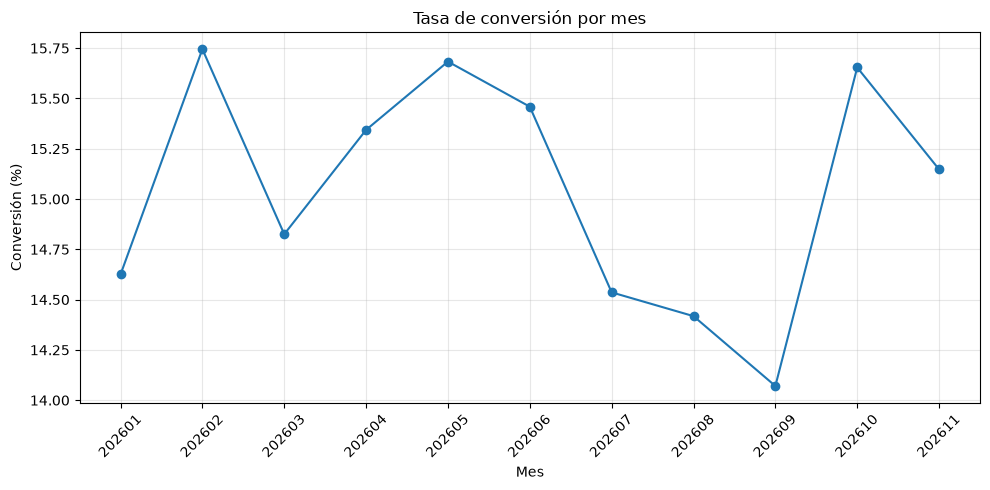

In [34]:
import matplotlib.pyplot as plt

# TASA DE CONVERSIÓN POR MES
conversion_mensual = (
    train.groupby("mes")["objetivo"]
    .mean()
    .mul(100)
)

plt.figure(figsize=(10, 5))
plt.plot(
    conversion_mensual.index.astype(str),
    conversion_mensual.values,
    marker="o"
)

plt.title("Tasa de conversión por mes")
plt.xlabel("Mes")
plt.ylabel("Conversión (%)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

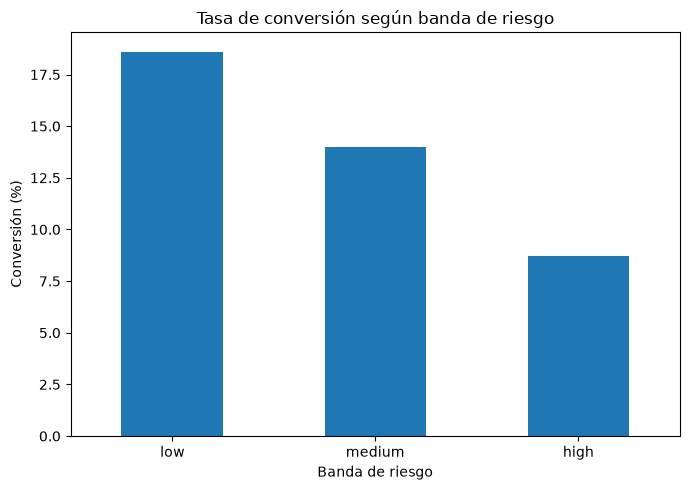

In [35]:
conversion_riesgo = (
    train.groupby("banda_riesgo")["objetivo"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(7, 5))
conversion_riesgo.plot(kind="bar")

plt.title("Tasa de conversión según banda de riesgo")
plt.xlabel("Banda de riesgo")
plt.ylabel("Conversión (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

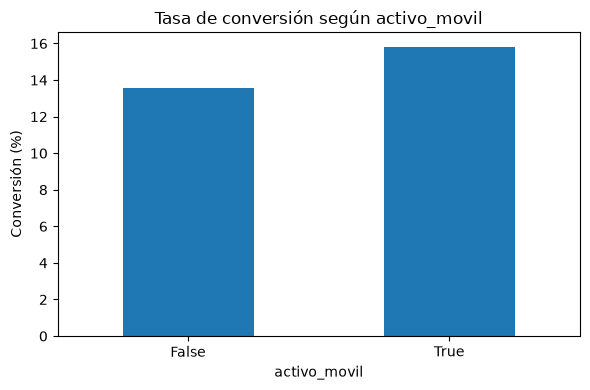

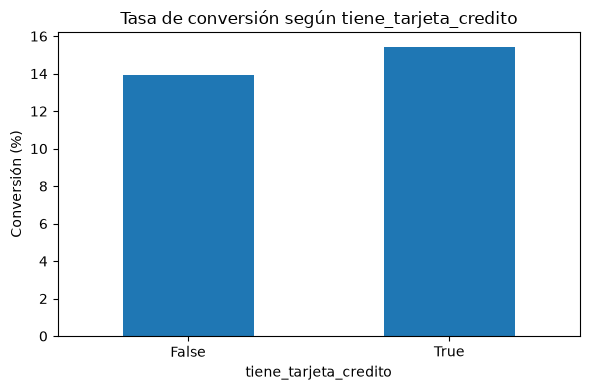

In [36]:
variables_booleanas = [
    "activo_movil",
    "tiene_tarjeta_credito",
]

for variable in variables_booleanas:

    tasa = (
        train.groupby(variable)["objetivo"]
        .mean()
        .mul(100)
    )

    plt.figure(figsize=(6, 4))
    tasa.plot(kind="bar")

    plt.title(f"Tasa de conversión según {variable}")
    plt.xlabel(variable)
    plt.ylabel("Conversión (%)")
    plt.xticks(rotation=0)

    plt.tight_layout()
    plt.show()

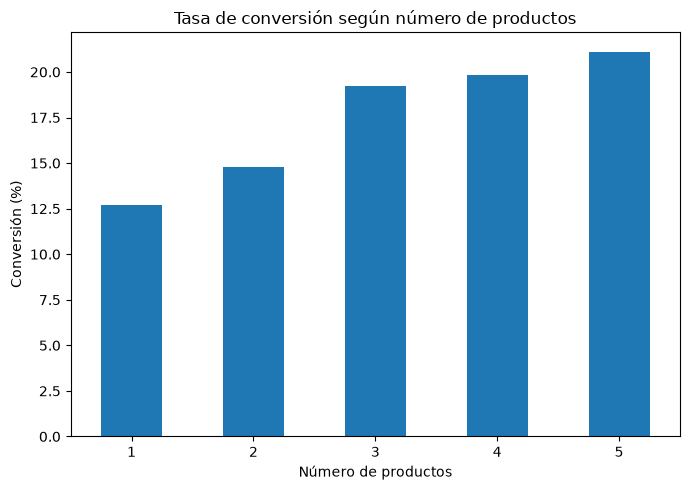

In [37]:
tasa_productos = (
    train.groupby("numero_productos")["objetivo"]
    .mean()
    .mul(100)
)

plt.figure(figsize=(7, 5))
tasa_productos.plot(kind="bar")

plt.title("Tasa de conversión según número de productos")
plt.xlabel("Número de productos")
plt.ylabel("Conversión (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

<Figure size 700x500 with 0 Axes>

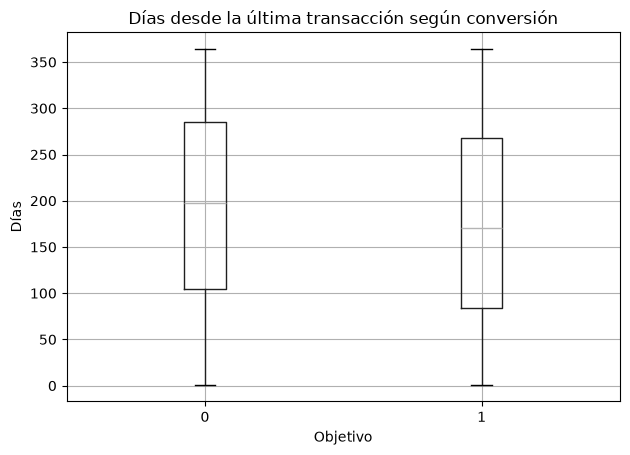

In [38]:
plt.figure(figsize=(7, 5))

train.boxplot(
    column="dias_ultima_transaccion",
    by="objetivo"
)

plt.title("Días desde la última transacción según conversión")
plt.suptitle("")
plt.xlabel("Objetivo")
plt.ylabel("Días")

plt.tight_layout()
plt.show()